In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
np.random.seed(1)

In [17]:
# Loading clean data.

df = pd.read_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\data\processed\stroop-cleaned.csv")

In [18]:
# Defining model parameters.

baseline_rt = 0.67
neutral_cost = 0.02
interference_cost = 0.10633
noise_sd = 0.22

In [19]:
# Defining number of simulated trials.

n_trials = 10000

In [20]:
# Generating conditions.

conditions = np.random.choice(
    ["congruent", "neutral", "incongruent"],
    size=n_trials
)

In [21]:
# Simulating RTs.

rts = []

for condition in conditions:

    rt = baseline_rt

    rt += np.random.normal(
        loc=0,
        scale=noise_sd
    )

    if condition == "incongruent":
        rt += interference_cost

    if condition == "neutral":
        rt += neutral_cost

    rts.append(rt)

In [22]:
# Creating simulated dataset.

simulated = pd.DataFrame({
    "condition": conditions,
    "RT": rts
})

print(simulated.head())

   condition        RT
0    neutral  0.368434
1  congruent  0.171797
2  congruent  0.192118
3    neutral  0.870533
4    neutral -0.047563


In [23]:
# Verifying qualitative pattern.

simulated.groupby("condition")["RT"].mean()

condition
congruent      0.672541
incongruent    0.776113
neutral        0.699307
Name: RT, dtype: float64

In [24]:
# Verifying effect size.

means = simulated.groupby("condition")["RT"].mean()

effect = (means["incongruent"] - means["congruent"])

print(effect)

0.10357225302335371


In [25]:
# Saveing simulation output.

simulated.to_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\results\simulated-data.csv", index=False)

## Minimal Computational Model

A simple interference model was created to reproduce the qualitative Stroop pattern.

The model assumes that reaction time is generated by three components:

> RT = baseline processing speed + random noise + interference cost

Note: for incongruent trials, I added a fixed interference cost to the baseline reaction time.

The simulation successfully reproduced the expected pattern, with incongruent trials producing slower reaction times than congruent trials.

The purpose of this model is not parameter fitting or prediction. It demonstrates how a simple cognitive mechanism can generate the empirical pattern of the Stroop task.

In [26]:
# Comparing model and empirical data.

# Computing empirical means.

real_means = (
    df.groupby("condition")["RT"]
    .mean()
)

print("Empirical mean:\n", real_means)

# Computing simulated means.

sim_means = (
    simulated.groupby("condition")["RT"]
    .mean()
)

print("\nSimulated mean:\n", sim_means)

# Creating comparison table.

comparison = pd.DataFrame({
    "real": real_means,
    "simulated": sim_means
})

print("\nComparison table:\n", comparison)

Empirical mean:
 condition
congruent      0.673524
incongruent    0.777733
neutral        0.689851
Name: RT, dtype: float64

Simulated mean:
 condition
congruent      0.672541
incongruent    0.776113
neutral        0.699307
Name: RT, dtype: float64

Comparison table:
                  real  simulated
condition                       
congruent    0.673524   0.672541
incongruent  0.777733   0.776113
neutral      0.689851   0.699307


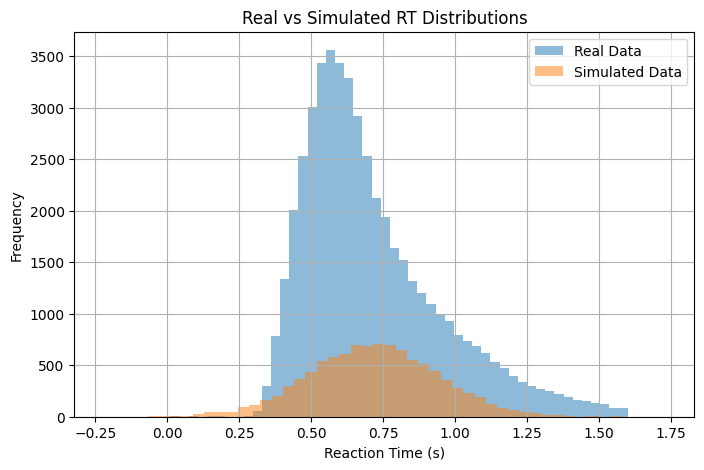

In [27]:
# Creating distribution figure.

plt.figure(figsize=(8, 5))

df["RT"].hist(
    bins=50,
    alpha=0.5,
    label="Real Data"
)

simulated["RT"].hist(
    bins=50,
    alpha=0.5,
    label="Simulated Data"
)

plt.xlabel("Reaction Time (s)")
plt.ylabel("Frequency")
plt.title("Real vs Simulated RT Distributions")

plt.legend()

# Save comparison figure.

plt.savefig(
    r"F:\doc-hub\education\psychology\projects\research\stroop-interference\figures\model-vs-data.png",
    bbox_inches="tight"
)

plt.show()